# 1. Data collection

Download and parse the inputs used in the rest of the project:

- **Polymarket** FOMC contracts via the Gamma API (metadata) and CLOB API (daily yes-token prices)
- **FRED** target federal funds upper bound
- **CME** 30-day Fed Funds futures (`ZQ=F`) via Yahoo Finance

Outputs written to this folder:

- `fed_rates_fred.csv`
- `fed_rates_and_futures.csv`
- `polymarket_fed_predictions_parsed_uncleaned.csv` (all overlapping meetings)
- `polymarket_fed_predictions_parsed.csv` (front-month / nearest meeting only)

Processed CSVs are already in the repo, so this notebook is only needed to refresh the data.

In [48]:
import requests
import pandas as pd
import time
import json
import seaborn as sns
import matplotlib.pyplot as plt
#Fed Interest Rates: March 2024
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import gaussian_kde
import numpy as np
import requests
import pandas as pd
import pandas_datareader.data as web
import datetime
import time
import json
import re
import yfinance as yf

In [3]:

def get_event_markets(slug):
    """
    Fetches the event metadata from the Gamma API using the event slug.
    (The slug is the last part of the URL: /event/fed-decision-in-december)
    """
    print(f"Fetching event data for: {slug}...")
    url = f"https://gamma-api.polymarket.com/events?slug={slug}"
    response = requests.get(url)
    
    if response.status_code != 200:
        print("Failed to fetch event from Gamma API.")
        return None
    
    data = response.json()
    if not data:
        print("Event not found.")
        return None
    
    # Gamma API returns a list, usually the exact match is the first item
    return data[0].get('markets', [])

def get_price_history(token_id, interval='all', fidelity=60):
    """
    Fetches the historical price data for a specific token from the CLOB API.
    fidelity=60 means 1-hour data granularity. Use fidelity=1440 for 1-day.
    """
    url = f"https://clob.polymarket.com/prices-history"
    params = {
        "market": token_id,
        "interval": interval,
        "fidelity": fidelity 
    }
    
    response = requests.get(url, params=params)
    if response.status_code != 200:
        print(f"Failed to fetch history for token: {token_id}")
        return []
    
    data = response.json()
    return data.get('history', [])

In [ ]:
event_slug = "fed-decision-in-december"

markets = get_event_markets(event_slug)


print(f"Found {len(markets)} options (markets) in this event.")

all_data = []

for market in markets:
    question = market.get('question', 'Unknown')
    group_item_title = market.get('groupItemTitle', question) 
    outcomes = json.loads(market.get('outcomes', '[]'))
    clob_token_ids = json.loads(market.get('clobTokenIds', '[]'))
    

    try:
        yes_index = outcomes.index("Yes")
        yes_token_id = clob_token_ids[yes_index]
    except (ValueError, IndexError):
        print(f"Could not find 'Yes' token for {group_item_title}. Skipping.")
        continue
        
    print(f"Downloading history for: {group_item_title} (Token: {yes_token_id})")
    
    history = get_price_history(yes_token_id, interval="all", fidelity=1440) # 1 hour intervals
    
    for point in history:
        all_data.append({
            "Option": group_item_title,
            "Timestamp": pd.to_datetime(point.get('t'), unit='s'), # Convert Unix timestamp
            "Price": float(point.get('p'))
        })
        
    # Polite delay to respect API limits
    time.sleep(1)

# if all_data:
#     # Save to CSV
#     df = pd.DataFrame(all_data)
#     filename = f"{event_slug}_history.csv"
#     df.to_csv(filename, index=False)
#     print(f"\nSuccess! Saved {len(df)} price points to {filename}.")
#     print(df.head())
# else:
#     print("No historical data found.")

Fetching event data for: fed-decision-in-december...
Found 4 options (markets) in this event.

Success! Saved 528 price points to fed-decision-in-december_history.csv.
             Option           Timestamp  Price
0  50+ bps decrease 2025-08-01 00:00:09  0.110
1  50+ bps decrease 2025-08-02 00:00:09  0.070
2  50+ bps decrease 2025-08-03 00:00:08  0.065
3  50+ bps decrease 2025-08-04 00:00:07  0.065
4  50+ bps decrease 2025-08-05 00:00:08  0.065


In [ ]:


print("Fetching baseline Fed Rates from FRED...")
start = datetime.datetime(2023, 1, 1) 
end = datetime.datetime.today()

df_fed = web.DataReader('DFEDTARU', 'fred', start, end)  # use DFEDTARL for floor, and DFF for effective rate, DFEDTARU for upper limit 
df_fed.reset_index(inplace=True)
df_fed.rename(columns={'DATE': 'Date', 'DFEDTARU': 'Upper_Fed_Rate'}, inplace=True)

date_range = pd.date_range(start=df_fed['Date'].min(), end=df_fed['Date'].max())
df_fed.set_index('Date', inplace=True)
df_fed = df_fed.reindex(date_range).ffill().reset_index()
df_fed.rename(columns={'index': 'Date'}, inplace=True)




Fetching baseline Fed Rates from FRED...


In [ ]:
start = datetime.datetime(2023, 1, 1)
end = datetime.datetime.today()
# DFF = Effective, DFEDTARU = Upper, DFEDTARL = Lower
series_ids = ['DFF', 'DFEDTARU', 'DFEDTARL']

print("Fetching Target Range and Effective Rate from FRED...")
df_fed = web.DataReader(series_ids, 'fred', start, end)

df_fed.rename(columns={
    'DFF': 'Effective_Rate',
    'DFEDTARU': 'Upper_Bound',
    'DFEDTARL': 'Lower_Bound'
}, inplace=True)

# ensures we have data for weekends when the Fed isn't "open"
date_range = pd.date_range(start=df_fed.index.min(), end=df_fed.index.max())
df_fed = df_fed.reindex(date_range).ffill()
df_fed.index.name = 'Date'
df_fed.reset_index(inplace=True)

fed_funds_futures = yf.download("ZQ=F", start=start, end=end)
fed_funds_futures['Implied_Rate_futures'] = 100 - fed_funds_futures['Close']
fed_funds_futures['Date'] = pd.to_datetime(fed_funds_futures.index)

Fetching Target Range and Effective Rate from FRED...


In [39]:
start = datetime.datetime(2023, 1, 1)
end = datetime.datetime.today()

series_ids = ['DFF', 'DFEDTARU', 'DFEDTARL']
df_fed = web.DataReader(series_ids, 'fred', start, end)
df_fed.rename(columns={'DFF': 'Effective_Rate', 'DFEDTARU': 'Upper_Bound', 'DFEDTARL': 'Lower_Bound'}, inplace=True)

date_range = pd.date_range(start=df_fed.index.min(), end=df_fed.index.max())
df_fed = df_fed.reindex(date_range).ffill()
df_fed.index.name = 'Date'
df_fed.reset_index(inplace=True)

fed_funds_futures = yf.download("ZQ=F", start=start, end=end)

fed_funds_futures.columns = fed_funds_futures.columns.get_level_values(0)

fed_funds_futures['Implied_Rate_futures'] = 100 - fed_funds_futures['Close']
fed_funds_futures.index.name = 'Date'
fed_funds_futures.reset_index(inplace=True)

df_master = pd.merge(df_fed, 
                     fed_funds_futures[['Date', 'Implied_Rate_futures']], 
                     on='Date', 
                     how='outer').sort_values('Date')

C:\Users\steph\AppData\Local\Temp\ipykernel_29968\1748029465.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  fed_funds_futures = yf.download("ZQ=F", start=start, end=end)
[*********************100%***********************]  1 of 1 completed


In [43]:
df_master.ffill(inplace=True)

In [45]:
df_master.dropna(inplace=True)

In [46]:
df_master.to_csv("fed_rates_and_futures.csv", index=False)

In [ ]:
fed_funds_futures = yf.download("ZQ=F", start=start, end=end)
fed_funds_futures['Implied_Rate_futures'] = 100 - fed_funds_futures['Close']
fed_funds_futures['Date'] = fed_funds_futures.index

In [106]:
df_fed_true = web.DataReader('DFF', 'fred', start, end)
df_fed_true.reset_index(inplace=True)
df_fed_true.rename(columns={'DATE': 'Date', 'DFEDTARU': 'Actual_Fed_Rate'}, inplace=True)

# Forward fill so we have a value for every single calendar day
date_range = pd.date_range(start=df_fed_true['Date'].min(), end=df_fed_true['Date'].max())
df_fed_true.set_index('Date', inplace=True)
df_fed_true = df_fed_true.reindex(date_range).ffill().reset_index()
df_fed_true.rename(columns={'index': 'Date'}, inplace=True)

In [ ]:
# df_fed.to_csv("fed_rates_fred.csv", index=False)

In [ ]:

# AUTO-GENERATE SLUGS & FETCH POLYMARKET DATA 
months = ["january", "february", "march", "april", "may", "june", 
          "july", "august", "september", "october", "november", "december"]
years = ["2023", "2024", "2025", "2026"]

all_polymarket_data = []

print("Scanning for Polymarket events...")
for year in years:
    for month in months:
        # Polymarket naming conventions change, we try common patterns
        patterns_to_try = [
            f"fed-interest-rates-{month}-{year}",
            f"fed-decision-in-{month}-{year}",
            f"fed-decision-in-{month}" 
        ]
        
        event_markets = None
        successful_slug = None
        
        for slug in patterns_to_try:
            url = f"https://gamma-api.polymarket.com/events?slug={slug}"
            response = requests.get(url)
            
            if response.status_code == 200 and len(response.json()) > 0:
                event_markets = response.json()[0].get('markets', [])
                successful_slug = slug
                break # Stop if a match
                
        if not event_markets:
            continue # No event found for this month/year combo
            
        print(f"Found event: {successful_slug} ({len(event_markets)} options)")
        
        # get the historical prices for each option in this event
        for market in event_markets:
            group_item_title = market.get('groupItemTitle', market.get('question', 'Unknown'))
            outcomes = json.loads(market.get('outcomes', '[]'))
            clob_token_ids = json.loads(market.get('clobTokenIds', '[]'))
            
            try:
                yes_index = outcomes.index("Yes")
                yes_token_id = clob_token_ids[yes_index]
            except (ValueError, IndexError):
                continue
                
            history_url = "https://clob.polymarket.com/prices-history"
            params = {"market": yes_token_id, "interval": "all", "fidelity": 1440} # Daily data
            hist_response = requests.get(history_url, params=params)
            
            if hist_response.status_code == 200:
                history = hist_response.json().get('history', [])
                for point in history:
                    all_polymarket_data.append({
                        "Event_Slug": successful_slug,
                        "Target_Month": month.capitalize(),
                        "Target_Year": year,
                        "Option": group_item_title,
                        "Date": pd.to_datetime(point.get('t'), unit='s').normalize(),
                        "Implied_Probability": float(point.get('p'))
                    })
            time.sleep(0.5) # API Rate limit buffer


print("Compiling data and parsing bins...")
df_poly = pd.DataFrame(all_polymarket_data)
final_df = pd.merge(df_poly, df_fed, on='Date', how='left')



Scanning for Polymarket events...
Found event: fed-decision-in-january (4 options)
Found event: fed-interest-rates-february-2023 (4 options)
Found event: fed-interest-rates-march-2023 (4 options)
Found event: fed-decision-in-april (4 options)
Found event: fed-interest-rates-may-2023 (4 options)
Found event: fed-interest-rates-june-2023 (4 options)
Found event: fed-interest-rates-july-2023 (3 options)
Found event: fed-interest-rates-september-2023 (2 options)
Found event: fed-decision-in-october (4 options)
Found event: fed-interest-rates-november-2023 (2 options)
Found event: fed-interest-rates-december-2023 (2 options)
Found event: fed-interest-rates-january-2024 (3 options)
Found event: fed-interest-rates-march-2024 (4 options)
Found event: fed-decision-in-april (4 options)
Found event: fed-interest-rates-may-2024 (4 options)
Found event: fed-interest-rates-june-2024 (4 options)
Found event: fed-interest-rates-july-2024 (4 options)
Found event: fed-interest-rates-september-2024 (4 op

In [ ]:
last_trading_dates = final_df.groupby('Event_Slug')['Date'].max().reset_index()


# .dt.strftime('%B') gets the full month name (e.g., "December")
last_trading_dates['True_Target_Year'] = last_trading_dates['Date'].dt.year
last_trading_dates['True_Target_Month'] = last_trading_dates['Date'].dt.strftime('%B')

mapping_df = last_trading_dates[['Event_Slug', 'True_Target_Year', 'True_Target_Month']]

corrected_df = final_df.drop(columns=['Target_Year', 'Target_Month'])

corrected_df = pd.merge(corrected_df, mapping_df, on='Event_Slug', how='left')

corrected_df.rename(columns={
    'True_Target_Year': 'Target_Year',
    'True_Target_Month': 'Target_Month'
}, inplace=True)


cols = corrected_df.columns.tolist()
# Move Target_Year and Target_Month right after Event_Slug
cols.insert(1, cols.pop(cols.index('Target_Month')))
cols.insert(2, cols.pop(cols.index('Target_Year')))
corrected_df = corrected_df[cols]



Dataframe corrected based on final trading dates!


,Event_Slug,Target_Month,Target_Year,Option,Date,Implied_Probability,Actual_Fed_Rate
0,fed-decision-in-january,January,2026,50+ bps decrease,2025-09-18,0.120,4.25
1,fed-decision-in-january,January,2026,50+ bps decrease,2025-09-19,0.105,4.25
2,fed-decision-in-january,January,2026,50+ bps decrease,2025-09-20,0.125,4.25
3,fed-decision-in-january,January,2026,50+ bps decrease,2025-09-21,0.085,4.25
4,fed-decision-in-january,January,2026,50+ bps decrease,2025-09-22,0.110,4.25


## Front-month contracts (one meeting at a time)

In [ ]:
meeting_dates = corrected_df.groupby('Event_Slug')['Date'].max().reset_index()
meeting_dates.rename(columns={'Date': 'Meeting_Date'}, inplace=True)

meeting_dates.sort_values('Meeting_Date', inplace=True)

# The market becomes the "front-month" the day AFTER the previous meeting finishes.
meeting_dates['Previous_Meeting_Date'] = meeting_dates['Meeting_Date'].shift(1)
meeting_dates['Start_Window'] = meeting_dates['Previous_Meeting_Date'] + pd.Timedelta(days=1)

# the very first event in our dataset, it has no "previous" meeting.
# set its start window to the absolute first day it started trading.
first_event_slug = meeting_dates.iloc[0]['Event_Slug']
first_event_min_date = corrected_df[corrected_df['Event_Slug'] == first_event_slug]['Date'].min()
meeting_dates.fillna({'Start_Window': first_event_min_date}, inplace=True)

# Merge these strict time windows back into our main dataset
front_month_df = pd.merge(corrected_df, meeting_dates[['Event_Slug', 'Start_Window', 'Meeting_Date']], on='Event_Slug', how='left')

# Keep only the rows where the trading Date 
# This eliminates all the early speculative trading months prior.
front_month_df = front_month_df[
    (front_month_df['Date'] >= front_month_df['Start_Window']) & 
    (front_month_df['Date'] <= front_month_df['Meeting_Date'])
]

front_month_df.drop(columns=['Start_Window', 'Meeting_Date'], inplace=True)

front_month_df.sort_values('Date', inplace=True)

In [160]:
front_month_df

,Event_Slug,Target_Month,Target_Year,Option,Date,Implied_Probability,Actual_Fed_Rate
1946,fed-interest-rates-may-2023,May,2023,0 bps increase after May meeting?,2023-03-23,0.5000,5.00
2099,fed-interest-rates-may-2023,May,2023,50 bps increase after May meeting?,2023-03-23,0.0500,5.00
2048,fed-interest-rates-may-2023,May,2023,25 bps increase after May meeting?,2023-03-23,0.4600,5.00
1997,fed-interest-rates-may-2023,May,2023,25 bps decrease after May meeting?,2023-03-23,0.0600,5.00
2100,fed-interest-rates-may-2023,May,2023,50 bps increase after May meeting?,2023-03-24,0.0300,5.00
...,...,...,...,...,...,...,...
12544,fed-decision-in-april,April,2026,25+ bps increase,2026-04-03,0.0065,3.75
3790,fed-decision-in-april,April,2026,50+ bps decrease,2026-04-03,0.0045,3.75
3789,fed-decision-in-april,April,2026,50+ bps decrease,2026-04-03,0.0045,3.75
3922,fed-decision-in-april,April,2026,25 bps decrease,2026-04-03,0.0075,3.75


## Multi-contract panel (all listed FOMC meetings)

In [ ]:
# df_parsed = front_month_df.copy()
df_parsed = corrected_df.copy()

def parse_option(row):
    """
    Parses the Polymarket text string into numeric rate shifts and bound types.
    Example: "50+ bps decrease" -> Shift: -0.50, Type: "Lower Bound"
    """
    option = str(row['Option']).lower()
    
    if "no change" in option:
        return pd.Series([0.0, "Exact_Bin"])
        
    match = re.search(r'(\d+)(\+?)\s*bps\s*(increase|decrease)', option)
    if match:
        bps_val = float(match.group(1)) / 100  # Convert bps to percentage points (25 -> 0.25)
        has_plus = match.group(2) == '+'
        direction = match.group(3)
        
        shift = bps_val if direction == 'increase' else -bps_val
        
        if has_plus and direction == 'increase':
            bound_type = "Upper_Bound"
        elif has_plus and direction == 'decrease':
            bound_type = "Lower_Bound"
        else:
            bound_type = "Exact_Bin"
            
        return pd.Series([shift, bound_type])
        
    return pd.Series([None, "Unknown"])

df_parsed[['Rate_Shift', 'Bin_Type']] = df_parsed.apply(parse_option, axis=1)

# calculate what the absolute Fed rate prediction is for this specific token
df_parsed['Implied_Fed_Rate_Target'] = df_parsed['Actual_Fed_Rate'] + df_parsed['Rate_Shift']

df_parsed.dropna(subset=['Actual_Fed_Rate', 'Rate_Shift'], inplace=True)
df_parsed.sort_values(by=['Target_Year', 'Target_Month', 'Date'], inplace=True)



In [176]:
df_parsed.to_csv("polymarket_fed_predictions_parsed_uncleaned.csv", index=False)  

In [50]:
df_parsed = pd.read_csv("polymarket_fed_predictions_parsed_uncleaned.csv")  

In [153]:
df_parsed['Event_Slug'].unique()

array(['fed-interest-rates-december-2023', 'fed-interest-rates-july-2023',
       'fed-interest-rates-june-2023', 'fed-interest-rates-february-2023',
       'fed-interest-rates-march-2023', 'fed-interest-rates-may-2023',
       'fed-interest-rates-november-2023',
       'fed-interest-rates-september-2023',
       'fed-interest-rates-december-2024',
       'fed-interest-rates-january-2024', 'fed-interest-rates-july-2024',
       'fed-interest-rates-june-2024', 'fed-interest-rates-march-2024',
       'fed-interest-rates-may-2024', 'fed-interest-rates-november-2024',
       'fed-interest-rates-september-2024', 'fed-decision-in-december',
       'fed-interest-rates-january-2025', 'fed-decision-in-july',
       'fed-decision-in-june', 'fed-decision-in-march',
       'fed-decision-in-may-2025', 'fed-decision-in-october',
       'fed-decision-in-september', 'fed-decision-in-april',
       'fed-decision-in-january'], dtype=object)

In [158]:
df_parsed.loc[df_parsed['Event_Slug']=='fed-decision-in-december']

,Event_Slug,Target_Month,Target_Year,Option,Date,Implied_Probability,Actual_Fed_Rate,Rate_Shift,Bin_Type,Implied_Fed_Rate_Target
10573,fed-decision-in-december,December,2025,50+ bps decrease,2025-08-01,0.1100,4.5,-0.50,Lower_Bound,4.00
10705,fed-decision-in-december,December,2025,25 bps decrease,2025-08-01,0.5750,4.5,-0.25,Exact_Bin,4.25
10837,fed-decision-in-december,December,2025,No change,2025-08-01,0.3850,4.5,0.00,Exact_Bin,4.50
10969,fed-decision-in-december,December,2025,25+ bps increase,2025-08-01,0.0600,4.5,0.25,Upper_Bound,4.75
14663,fed-decision-in-december,December,2025,50+ bps decrease,2025-08-01,0.1100,4.5,-0.50,Lower_Bound,4.00
...,...,...,...,...,...,...,...,...,...,...
11100,fed-decision-in-december,December,2025,25+ bps increase,2025-12-10,0.0005,4.0,0.25,Upper_Bound,4.25
14794,fed-decision-in-december,December,2025,50+ bps decrease,2025-12-10,0.0045,4.0,-0.50,Lower_Bound,3.50
14926,fed-decision-in-december,December,2025,25 bps decrease,2025-12-10,0.9685,4.0,-0.25,Exact_Bin,3.75
15058,fed-decision-in-december,December,2025,No change,2025-12-10,0.0280,4.0,0.00,Exact_Bin,4.00


In [90]:
df_parsed.loc[df_parsed['Event_Slug']=='fed-decision-in-december']

,Event_Slug,Target_Month,Target_Year,Option,Date,Implied_Probability,Actual_Fed_Rate,Rate_Shift,Bin_Type,Implied_Fed_Rate_Target
3627,fed-decision-in-december,December,2025,50+ bps decrease,2025-08-01,0.1100,4.5,-0.50,Lower_Bound,4.00
3628,fed-decision-in-december,December,2025,25 bps decrease,2025-08-01,0.5750,4.5,-0.25,Exact_Bin,4.25
3629,fed-decision-in-december,December,2025,No change,2025-08-01,0.3850,4.5,0.00,Exact_Bin,4.50
3630,fed-decision-in-december,December,2025,25+ bps increase,2025-08-01,0.0600,4.5,0.25,Upper_Bound,4.75
3631,fed-decision-in-december,December,2025,50+ bps decrease,2025-08-01,0.1100,4.5,-0.50,Lower_Bound,4.00
...,...,...,...,...,...,...,...,...,...,...
4678,fed-decision-in-december,December,2025,25+ bps increase,2025-12-10,0.0005,4.0,0.25,Upper_Bound,4.25
4679,fed-decision-in-december,December,2025,50+ bps decrease,2025-12-10,0.0045,4.0,-0.50,Lower_Bound,3.50
4680,fed-decision-in-december,December,2025,25 bps decrease,2025-12-10,0.9685,4.0,-0.25,Exact_Bin,3.75
4681,fed-decision-in-december,December,2025,No change,2025-12-10,0.0280,4.0,0.00,Exact_Bin,4.00


In [52]:
test1=df_parsed.loc[df_parsed['Event_Slug']=='fed-decision-in-december',['Date','Option','Implied_Probability']].drop_duplicates()
test1 = test1.pivot(index='Date', columns='Option', values='Implied_Probability')
test2=df_parsed.loc[df_parsed['Event_Slug']=='fed-decision-in-october',['Date','Option','Implied_Probability']].drop_duplicates()
test2 = test2.pivot(index='Date', columns='Option', values='Implied_Probability')


In [55]:
test1.index = pd.to_datetime(test1.index)

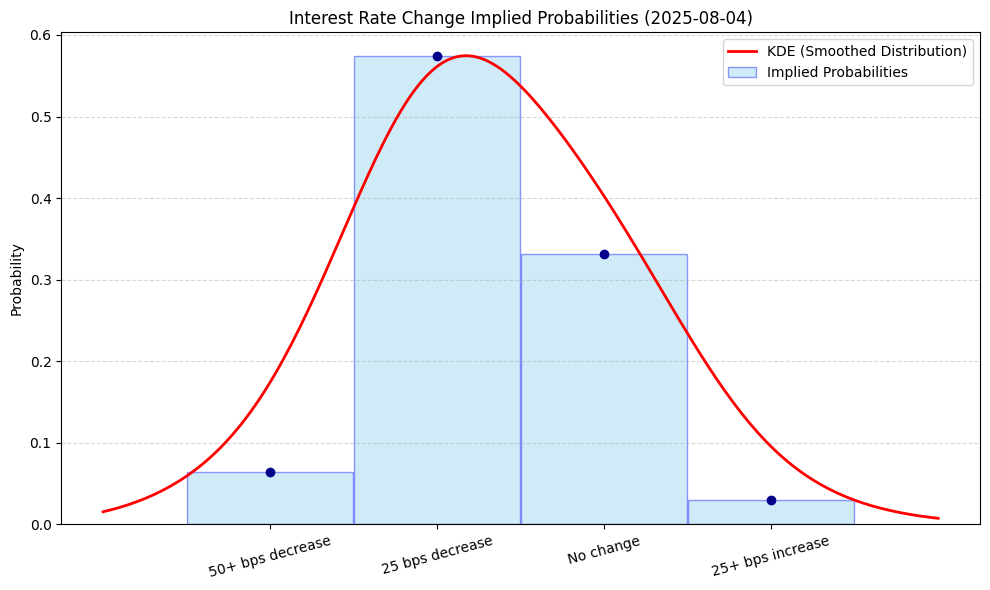

In [84]:
categories = ['50+ bps decrease', '25 bps decrease', 'No change', '25+ bps increase']
probs = [0.0650, 0.5800, 0.3350, 0.0295] # Data from '2025-08-04'

probs = np.array(probs) / np.sum(probs)
x_values = np.array([-0.50, -0.25, 0.00, 0.25])


kde = gaussian_kde(x_values, weights=probs, bw_method=0.7)
x_fine = np.linspace(-0.75, 0.5, 200)
y_kde = kde(x_fine)

plt.figure(figsize=(10, 6))

plt.bar(x_values, probs, width=0.248, alpha=0.4, color='skyblue', 
        label='Implied Probabilities', edgecolor='blue')


y_kde_scaled = y_kde * (max(probs) / max(y_kde))
plt.plot(x_fine, y_kde_scaled, color='red', lw=2, label='KDE (Smoothed Distribution)')

plt.scatter(x_values, probs, color='darkblue', zorder=5)

plt.xticks(x_values, categories, rotation=15)
plt.ylabel('Probability')
plt.title('Interest Rate Change Implied Probabilities (2025-08-04)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

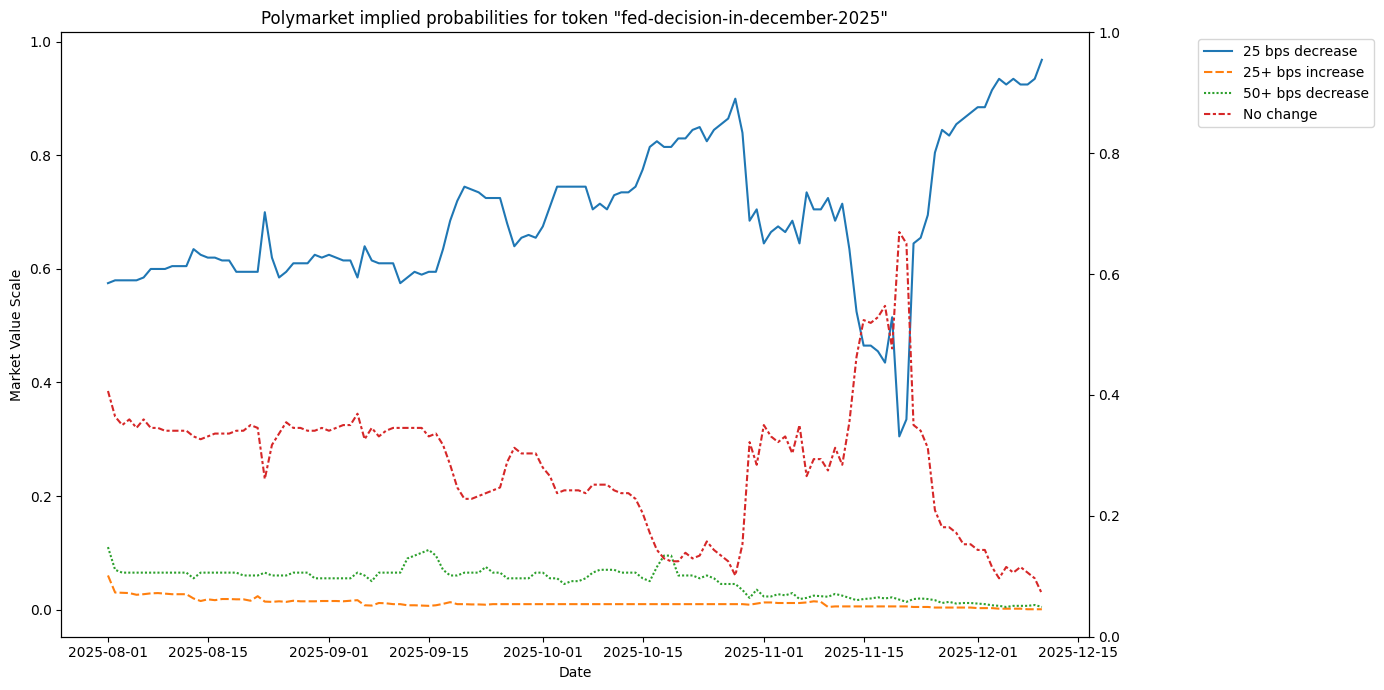

In [65]:
start_date = test1.index.min()
end_date = test1.index.max()+pd.Timedelta(days=10)
df_fed_filtered = df_fed[(df_fed['Date'] >= start_date) & (df_fed['Date'] <= end_date)]

fig, ax1 = plt.subplots(figsize=(14, 7))

colors = sns.color_palette("tab10", 9)

sns.lineplot(data=test1, palette=colors[:4], ax=ax1)
# sns.lineplot(data=test2, palette=colors[4:8], ax=ax1)
ax1.set_ylabel('Market Value Scale')

ax2 = ax1.twinx()
# sns.lineplot(x='Date', y='Upper_Fed_Rate', data=df_fed_filtered, 
#              color=colors[8], label='Fed Rate', ax=ax2, linewidth=2.5)
# ax2.set_ylabel('Federal Funds Rate (%)')


lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.get_legend().remove() 
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left', bbox_to_anchor=(1.1, 1))
plt.title('Polymarket implied probabilities for token "fed-decision-in-december-2025"')
plt.tight_layout()
plt.show()

In [91]:
test1.columns = [3.75,4.25,4.50,4]
test1 = test1.reindex(sorted(test1.columns), axis=1)

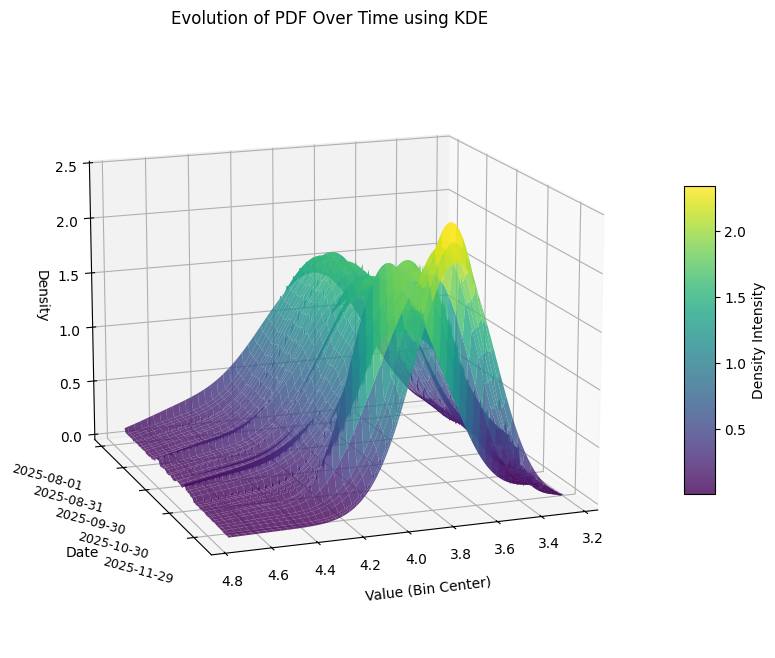

In [ ]:
bin_centers = test1.columns.astype(float).values


x_fine = np.linspace(3.25, 4.75, 100)   # The range of values (X-axis)
y_time = np.arange(len(test1))           # Timesteps (Y-axis)
X, Y = np.meshgrid(x_fine, y_time)
Z = np.zeros(X.shape)                 # Density (Z-axis)

for i in range(len(test1)):
    weights = test1.iloc[i].values
    # bw_method=0.3 provides a balance between smoothness and data fidelity
    kde = gaussian_kde(bin_centers, weights=weights, bw_method=0.7)
    Z[i, :] = kde(x_fine)
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.8)
stride = 30 
indices = np.arange(0, len(test1), stride)
date_labels = test1.index[indices].strftime('%Y-%m-%d')

ax.set_yticks(indices)
ax.set_yticklabels(date_labels, rotation=-15, ha='right', fontsize=9)

ax.set_xlabel('Value (Bin Center)', labelpad=10)
ax.set_ylabel('Date', labelpad=20)
ax.set_zlabel('Density')
ax.set_title('Evolution of PDF Over Time using KDE')

ax.view_init(elev=15, azim=70)
fig.colorbar(surf, shrink=0.5, aspect=10, label='Density Intensity')

plt.show()

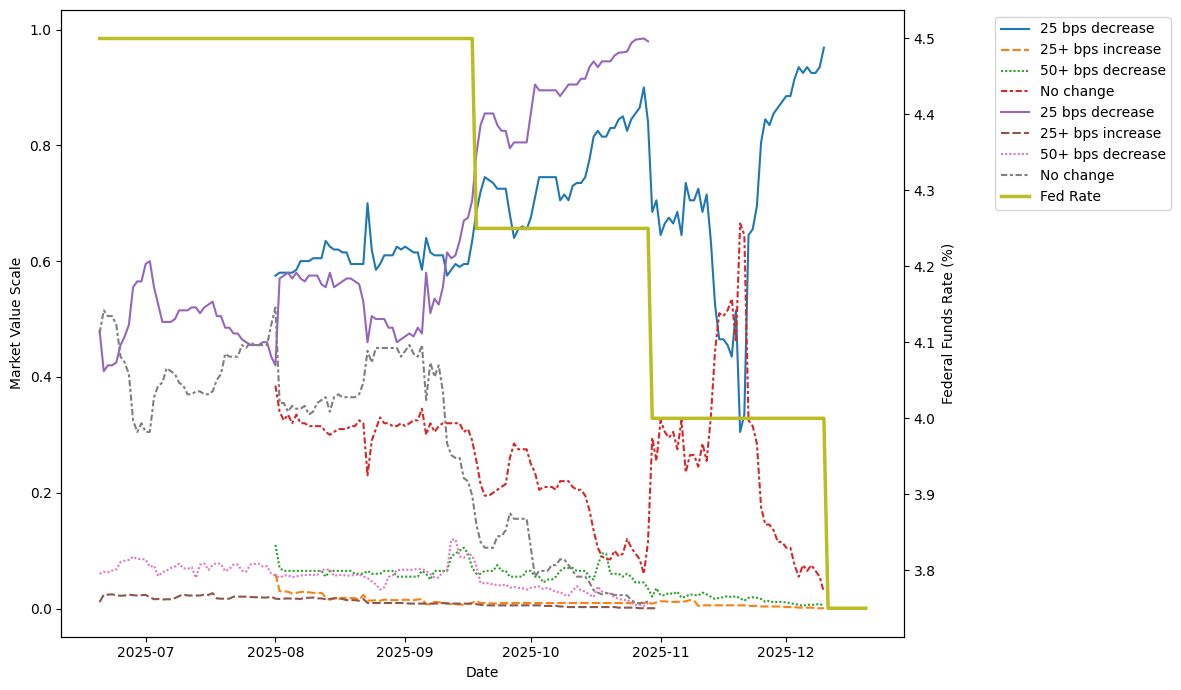

In [ ]:
start_date = test2.index.min()
end_date = test1.index.max()+pd.Timedelta(days=10)
df_fed_filtered = df_fed[(df_fed['Date'] >= start_date) & (df_fed['Date'] <= end_date)]

fig, ax1 = plt.subplots(figsize=(12, 7))

colors = sns.color_palette("tab10", 9)

sns.lineplot(data=test1, palette=colors[:4], ax=ax1)
sns.lineplot(data=test2, palette=colors[4:8], ax=ax1)
ax1.set_ylabel('Market Value Scale')

ax2 = ax1.twinx()
sns.lineplot(x='Date', y='Actual_Fed_Rate', data=df_fed_filtered, 
             color=colors[8], label='Fed Rate', ax=ax2, linewidth=2.5)
ax2.set_ylabel('Federal Funds Rate (%)')


lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.get_legend().remove() 
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left', bbox_to_anchor=(1.1, 1))

plt.tight_layout()
plt.show()


In [174]:
df_parsed.to_csv("polymarket_fed_predictions_parsed.csv", index=False)

In [87]:
df_parsed.loc[df_parsed['Event_Slug']=='fed-decision-in-december',['Date','Option','Implied_Probability']].drop_duplicates()

,Date,Option,Implied_Probability
3627,2025-08-01,50+ bps decrease,0.1100
3628,2025-08-01,25 bps decrease,0.5750
3629,2025-08-01,No change,0.3850
3630,2025-08-01,25+ bps increase,0.0600
3635,2025-08-02,50+ bps decrease,0.0700
...,...,...,...
4670,2025-12-09,25+ bps increase,0.0005
4675,2025-12-10,50+ bps decrease,0.0045
4676,2025-12-10,25 bps decrease,0.9685
4677,2025-12-10,No change,0.0280


In [ ]:
test1_v1=df_parsed.loc[df_parsed['Event_Slug']=='fed-decision-in-december',['Date','Option','Implied_Probability']].drop_duplicates()
test1_v1 = test1_v1.pivot(index='Date', columns='Option', values='Implied_Probability')
test2_v2=df_parsed.loc[df_parsed['Event_Slug']=='fed-decision-in-october',['Date','Option','Implied_Probability']].drop_duplicates()
test2_v2 = test2_v2.pivot(index='Date', columns='Option', values='Implied_Probability')

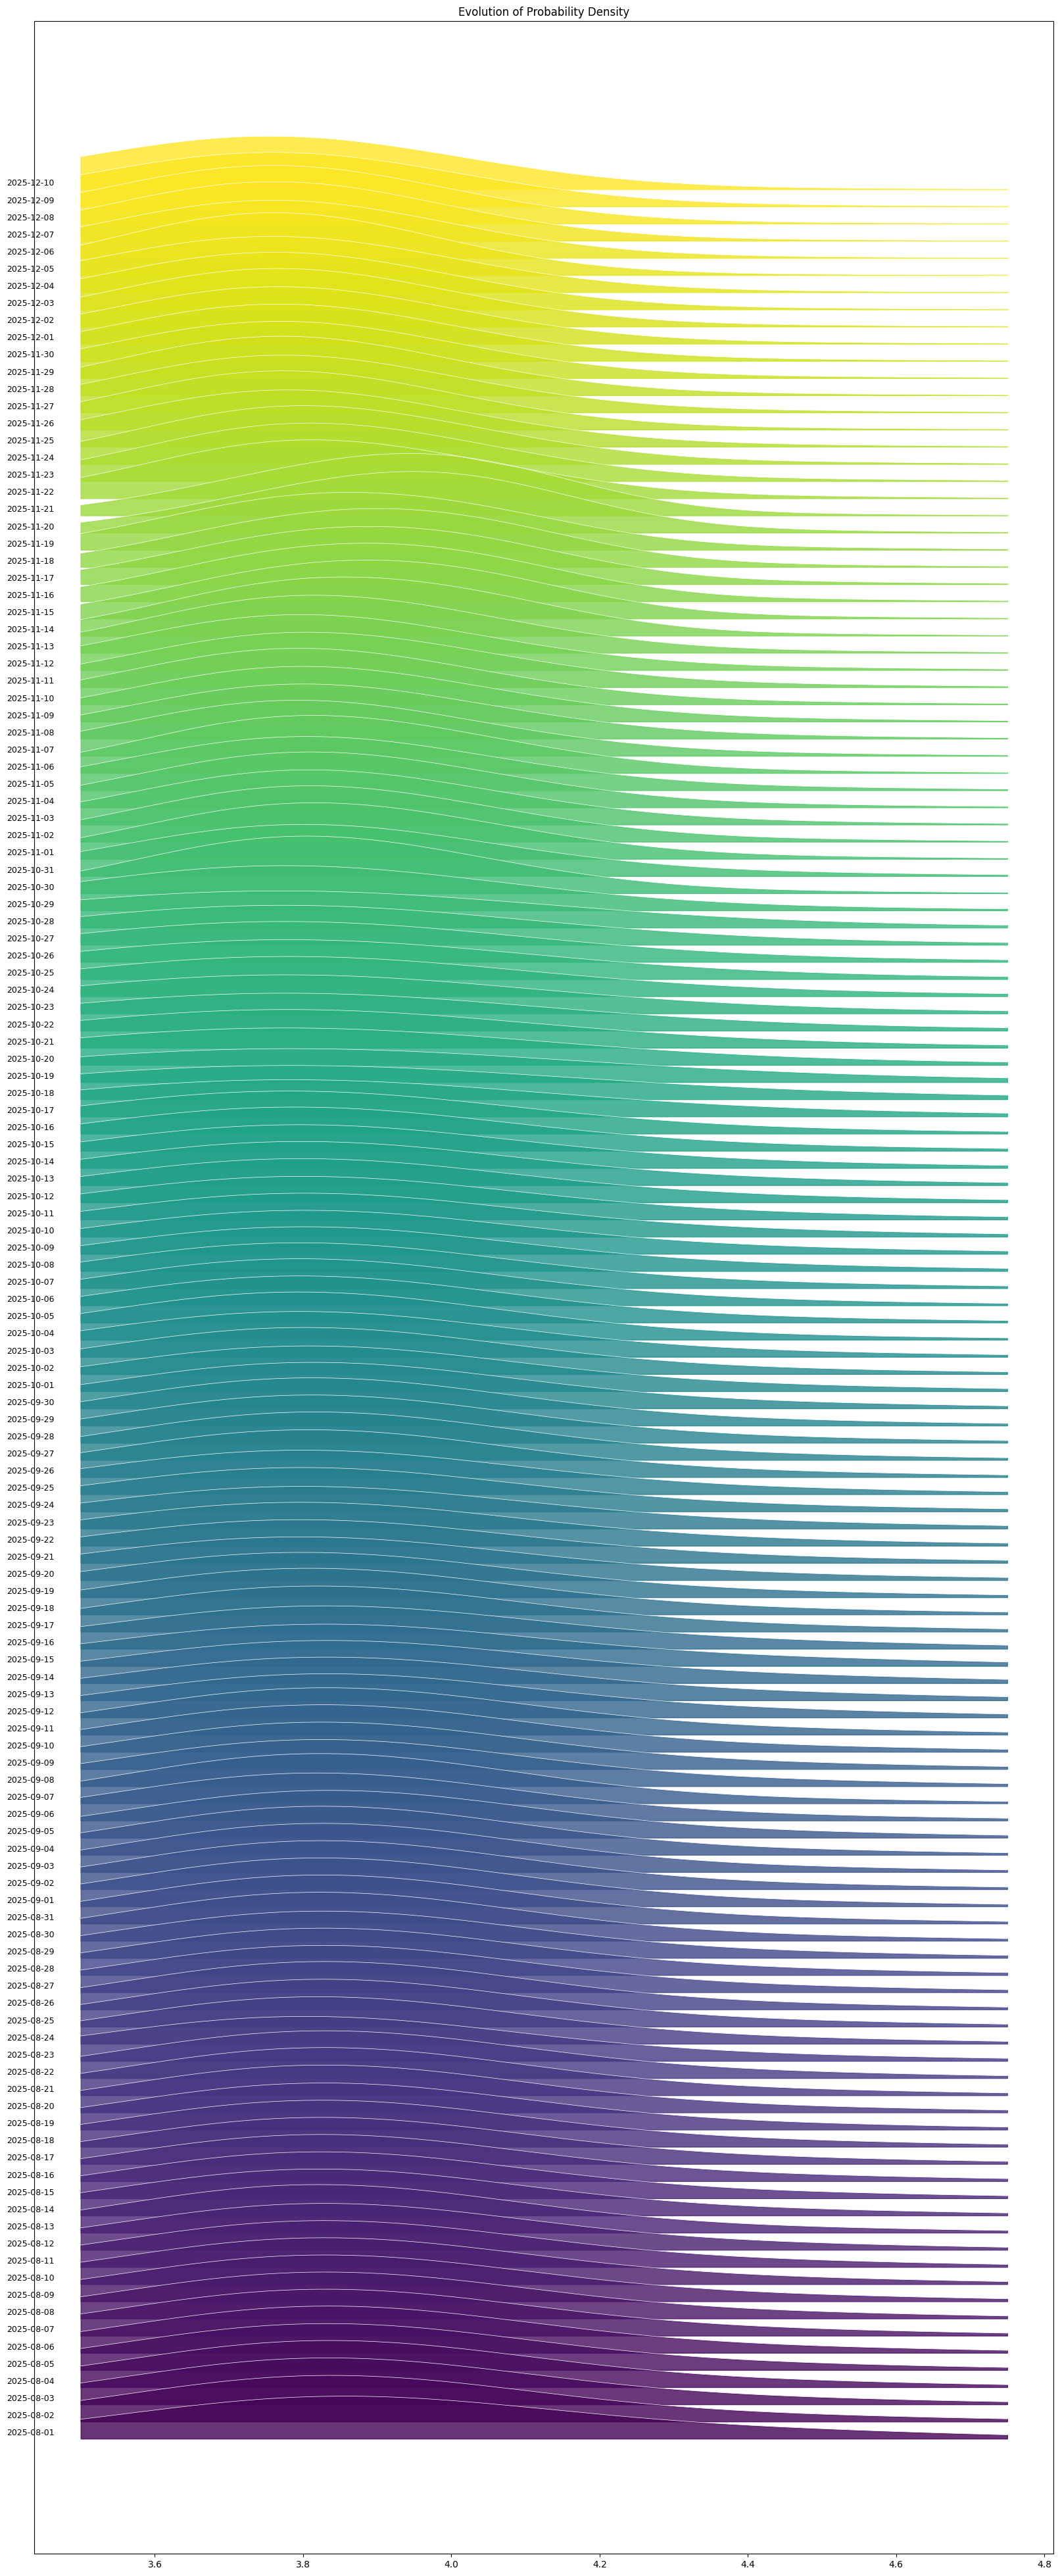

In [50]:
from scipy.stats import gaussian_kde
import numpy as np
# Setup plot
fig, ax = plt.subplots(figsize=(20, 50))
colors = plt.cm.viridis(np.linspace(0, 1, len(df_clean)))

x_fine = np.linspace(3.5, 4.75, 200)

for i, (ts, row) in enumerate(df_clean.iterrows()):
    # Create KDE for this specific day
    kde = gaussian_kde(df_clean.columns.astype(float), weights=row.values)
    y_fine = kde(x_fine)
    
    # Plot with a vertical offset to create the "ridge" effect
    offset = i * 0.5 
    ax.plot(x_fine, y_fine + offset, color='white', lw=0.5)
    ax.fill_between(x_fine, offset, y_fine + offset, color=colors[i], alpha=0.8)
    ax.text(3.4, offset + 0.1, ts.strftime('%Y-%m-%d'), fontsize=9)

ax.set_title("Evolution of Probability Density")
ax.set_yticks([]) # Hide Y ticks as they are just offsets
plt.show()